# Recitation: Supervised Learning with Cross-Validation

In this recitation, we will explore core supervised learning algorithms for both **regression** and **classification** tasks. We'll use **cross-validation** to evaluate models and learn how to choose good hyperparameters.

---

## What is Supervised Learning?

Supervised learning refers to training a model on a labeled dataset, where we know the correct output (target) for each input.

There are two main types of supervised learning tasks:

| Task Type     | Goal                                   | Example                        |
|---------------|----------------------------------------|--------------------------------|
| Regression     | Predict a continuous value             | Predict house prices, temperature |
| Classification | Predict a category or class label      | Detect spam email, diagnose disease |

---

## Algorithms We Will Cover

1. **k-Nearest Neighbors (kNN)**
   - Predict based on the labels of the nearest data points
   - Easy to understand, but sensitive to scaling and choice of *k*

2. **Decision Tree**
   - Learn a sequence of "if-else" rules to split the data
   - Easy to interpret, prone to overfitting if not pruned

3. **Random Forest**
   - An ensemble of decision trees with random sampling
   - More robust and generalizes better than a single tree

4. **XGBoost**
   - A powerful boosting algorithm that builds trees sequentially
   - Used in many winning Kaggle solutions

---

## Evaluation Strategy

For each model, we will:
- Run both a **regression** and a **classification** example
- Evaluate using appropriate metrics
- Use **cross-validation** to measure performance and tune hyperparameters

Next, we'll begin with **k-Nearest Neighbors** and see how to use cross-validation to select the best value of **k**.


## Section 2: k-Nearest Neighbors (kNN)

The k-Nearest Neighbors algorithm predicts the output of a new data point by looking at the **k closest training examples** in feature space.

- **Classification**: Predict the most common class among neighbors
- **Regression**: Predict the average value of neighbors

It is a **non-parametric** method — it doesn't learn a model during training, but uses the training data directly at prediction time.

---

### How to Choose k?

- A small k may lead to **overfitting** (too sensitive to noise)
- A large k may lead to **underfitting** (too smooth)

We’ll use **cross-validation** to select the best value of k.


In [32]:
from sklearn.datasets import make_regression, make_classification
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

# For classification report later
from sklearn.metrics import classification_report


### kNN Regression Example with Cross-Validation


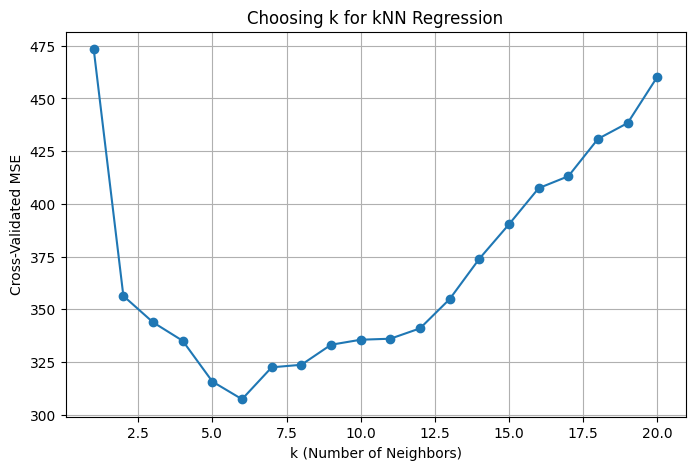

Best k: 6


In [33]:
# Generate synthetic regression data
X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)

# Try different values of k
k_values = list(range(1, 21))
cv_scores = []

for k in k_values:
    model = KNeighborsRegressor(n_neighbors=k)
    scores = cross_val_score(model, X_reg, y_reg, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())  # convert from negative MSE

# Plot k vs MSE
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Cross-Validated MSE")
plt.title("Choosing k for kNN Regression")
plt.grid(True)
plt.show()

best_k = k_values[np.argmin(cv_scores)]
print(f"Best k: {best_k}")


We used 5-fold cross-validation to compute the MSE for each value of k. The value with the **lowest MSE** is the best choice for this regression task.

---

### kNN Classification Example with Cross-Validation


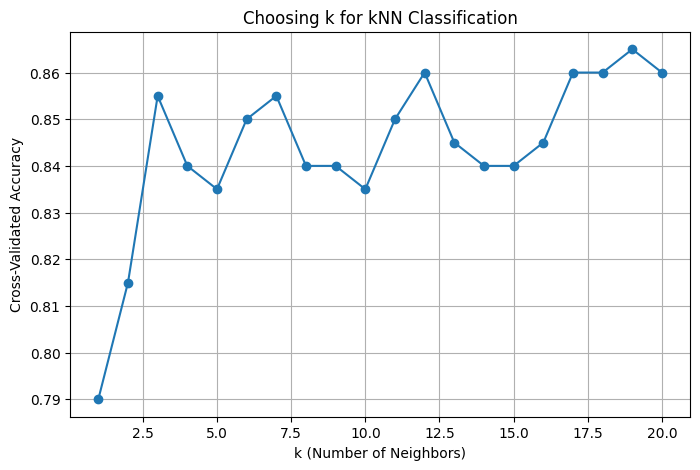

Best k: 19


In [34]:
# Generate synthetic classification data
X_clf, y_clf = make_classification(n_samples=200, n_features=2, n_informative=2,
                                   n_redundant=0, n_clusters_per_class=1, random_state=42)

# Try different values of k
k_values = list(range(1, 21))
cv_scores = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_clf, y_clf, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot k vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k (Number of Neighbors)")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Choosing k for kNN Classification")
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(cv_scores)]
print(f"Best k: {best_k}")


Here we used accuracy as the scoring metric. Again, we use cross-validation to select the best value of k for classification.

Next, we will look at **Decision Trees**, and how we can tune their depth and other hyperparameters.


### How to Choose `k` in kNN

The value of `k` — the number of neighbors — has a big effect on model behavior.

- **Small `k` (e.g., 1–3)**: model fits tightly to training data → high variance, low bias (can overfit)
- **Large `k` (e.g., >15)**: model becomes smoother → low variance, high bias (can underfit)

**Best Practice:**
- Use **cross-validation** (e.g., 5-fold) to try multiple values of `k`
- Choose the value with the **lowest cross-validated error** (regression) or **highest accuracy** (classification)
- Typical range to try: `k = 1` to `k = 20`

Always **scale your features** (e.g., with `StandardScaler`) before using kNN, since it's distance-based.


## Section 3: Decision Tree

A **Decision Tree** learns a set of "if-else" rules to split the data into smaller and smaller subsets based on feature values.

- Can be used for **both regression and classification**
- Easy to understand and interpret
- Prone to **overfitting** if not properly pruned

---

### Important Hyperparameters to Tune

| Hyperparameter       | Description                                 |
|----------------------|---------------------------------------------|
| `max_depth`          | Maximum depth of the tree                   |
| `min_samples_split`  | Minimum samples required to split a node    |
| `min_samples_leaf`   | Minimum samples required at a leaf node     |

We will use **cross-validation** to select the best `max_depth` for both regression and classification.


In [35]:
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier


### Decision Tree Regression with Cross-Validation


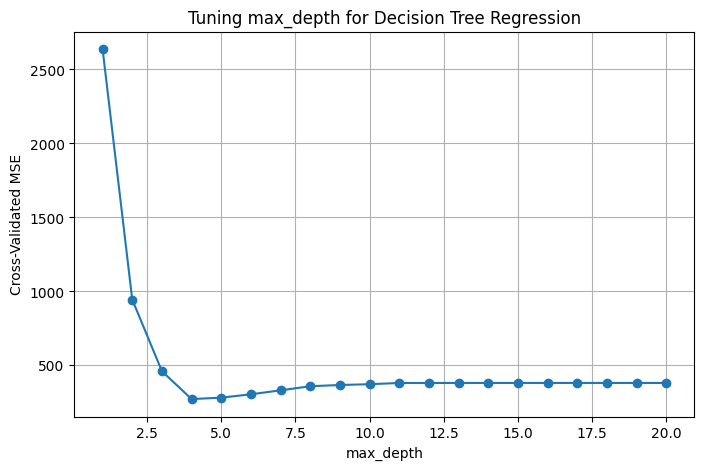

Best max_depth: 4


In [36]:
# Generate regression data
from sklearn.datasets import make_regression

X_reg, y_reg = make_regression(n_samples=200, n_features=1, noise=15, random_state=1)

depths = list(range(1, 21))
cv_scores = []

for d in depths:
    tree = DecisionTreeRegressor(max_depth=d, random_state=1)
    scores = cross_val_score(tree, X_reg, y_reg, cv=5, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depths, cv_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Cross-Validated MSE")
plt.title("Tuning max_depth for Decision Tree Regression")
plt.grid(True)
plt.show()

best_depth = depths[np.argmin(cv_scores)]
print(f"Best max_depth: {best_depth}")


Now let’s do the same for a classification problem.


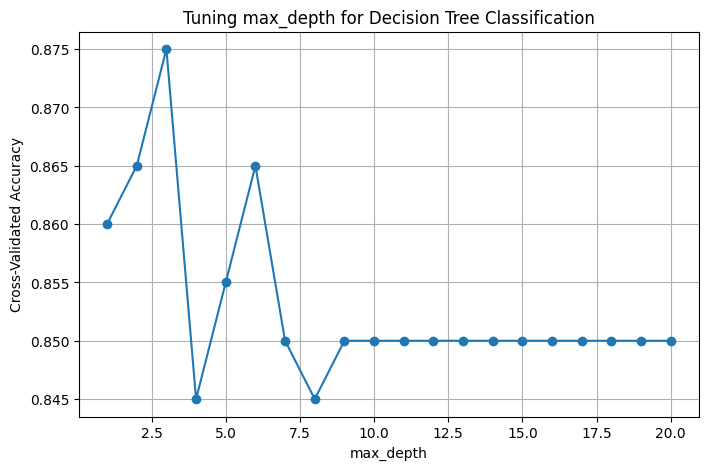

Best max_depth: 3


In [37]:
# Generate classification data
from sklearn.datasets import make_classification

X_clf, y_clf = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                   n_informative=2, n_clusters_per_class=1, random_state=1)

depths = list(range(1, 21))
cv_scores = []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=1)
    scores = cross_val_score(tree, X_clf, y_clf, cv=5, scoring='accuracy')
    cv_scores.append(scores.mean())

# Plot
plt.figure(figsize=(8, 5))
plt.plot(depths, cv_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("Cross-Validated Accuracy")
plt.title("Tuning max_depth for Decision Tree Classification")
plt.grid(True)
plt.show()

best_depth = depths[np.argmax(cv_scores)]
print(f"Best max_depth: {best_depth}")


By tuning `max_depth`, we can control how complex the tree is.

- A small depth → underfitting (not enough complexity)
- A large depth → overfitting (memorizes training data)

Next, we’ll look at **Random Forests**, which help reduce overfitting by combining many trees.


## Section 4: Random Forest

A **Random Forest** is an ensemble model that builds **many decision trees** and averages their predictions (for regression) or uses majority voting (for classification).

### Why Use Random Forests?

- More accurate than a single decision tree
- Reduces overfitting by averaging multiple trees
- Handles both regression and classification tasks well

---

### Important Hyperparameters to Tune

| Hyperparameter       | Description                                              |
|----------------------|----------------------------------------------------------|
| `n_estimators`       | Number of trees in the forest                            |
| `max_depth`          | Maximum depth of each individual tree                    |
| `max_features`       | Number of features to consider at each split             |
| `min_samples_leaf`   | Minimum samples required at a leaf node                  |

We will use **cross-validation** to tune `n_estimators` and `max_depth`.


In [38]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier


### Random Forest Regression with Cross-Validation


In [39]:
# Generate regression data again
from sklearn.datasets import make_regression
X_reg, y_reg = make_regression(n_samples=200, n_features=5, noise=20, random_state=42)

depths = [3, 5, 10, 15]
estimators = [10, 50, 100]
results = {}

for d in depths:
    for n in estimators:
        rf = RandomForestRegressor(n_estimators=n, max_depth=d, random_state=42)
        score = cross_val_score(rf, X_reg, y_reg, cv=5, scoring='neg_mean_squared_error').mean()
        results[(d, n)] = -score

# Find best combination
best_params = min(results, key=results.get)
print(f"Best max_depth: {best_params[0]}, Best n_estimators: {best_params[1]}")
print(f"Best CV MSE: {results[best_params]:.2f}")


Best max_depth: 10, Best n_estimators: 100
Best CV MSE: 1234.50


Now let’s do the same for a classification problem.


In [40]:
# Generate classification data
from sklearn.datasets import make_classification
X_clf, y_clf = make_classification(n_samples=200, n_features=5, n_informative=3,
                                   n_redundant=0, random_state=42)

depths = [3, 5, 10, 15]
estimators = [10, 50, 100]
results = {}

for d in depths:
    for n in estimators:
        rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42)
        score = cross_val_score(rf, X_clf, y_clf, cv=5, scoring='accuracy').mean()
        results[(d, n)] = score

# Best parameters
best_params = max(results, key=results.get)
print(f"Best max_depth: {best_params[0]}, Best n_estimators: {best_params[1]}")
print(f"Best CV Accuracy: {results[best_params]:.2f}")


Best max_depth: 5, Best n_estimators: 100
Best CV Accuracy: 0.90


Random Forests help reduce overfitting by averaging many decision trees.  
With cross-validation, we can select a good balance of depth and number of trees to maximize performance.

Next, we’ll introduce **XGBoost**, a powerful boosting algorithm.


## Section 5: XGBoost (Extreme Gradient Boosting)

**XGBoost** is a powerful and scalable machine learning algorithm based on **gradient boosting**.

It builds decision trees **sequentially**, where each tree tries to correct the errors of the previous one.

XGBoost is known for:
- High accuracy
- Speed and scalability
- Built-in support for missing values and regularization

---

### Key Hyperparameters

| Hyperparameter     | Description                                          |
|--------------------|------------------------------------------------------|
| `n_estimators`     | Number of boosting rounds (trees)                    |
| `max_depth`        | Maximum depth of individual trees                    |
| `learning_rate`    | Step size shrinkage (smaller values = slower but better) |
| `subsample`        | Fraction of training data used per boosting round    |

We’ll use cross-validation with `GridSearchCV` to find good values for these.


In [41]:
# Uncomment if not installed
# !pip install xgboost

import xgboost as xgb
from sklearn.model_selection import GridSearchCV


In [42]:
# Generate classification data
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=300, n_features=5, n_informative=3,
                           n_redundant=0, random_state=42)

# Define model
xgb_clf = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Define hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

# Grid search with cross-validation
grid = GridSearchCV(xgb_clf, param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)

print(f"Best Parameters: {grid.best_params_}")
print(f"Best Cross-Validated Accuracy: {grid.best_score_:.2f}")


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:18:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:18:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:18:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:18:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:18:50] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 50}
Best Cross-Validated Accuracy: 0.87


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [01:18:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


We used `GridSearchCV` to try different combinations of learning rate, number of trees, and tree depth.

XGBoost is one of the most popular models in practice and competitions like Kaggle because of its speed and accuracy.


### How to Choose Hyperparameters for Tree-Based Models

Tree models can **easily overfit** without proper constraints. The most important hyperparameters include:

#### 🔸 For Decision Trees:
- `max_depth`: Maximum tree depth. Shallow trees may underfit; deep trees may overfit.
- `min_samples_split`: Minimum number of samples to split a node.
- `min_samples_leaf`: Minimum samples at a leaf node.

#### 🔸 For Random Forest:
- `n_estimators`: Number of trees in the forest.
- `max_features`: Number of features to consider at each split. Smaller values = more randomness, lower variance.
- Same `max_depth` / `min_samples_leaf` also apply.

#### 🔸 For XGBoost:
- `n_estimators`: Number of boosting rounds.
- `learning_rate`: Shrinks the contribution of each tree (smaller = better, but slower).
- `max_depth`: Depth of each tree.
- `subsample`: Fraction of training data used in each round.

**Best Practice:**
- Use **GridSearchCV** or **RandomizedSearchCV** to explore combinations
- Start with a **small subset** of the parameter grid to save time
- Use **cross-validation scores** (e.g., accuracy, AUC, MSE) to pick the best settings


## Hyperparameter Tuning Summary

| Model           | Key Hyperparameters                  | Why It Matters                                |
|------------------|--------------------------------------|------------------------------------------------|
| kNN             | `n_neighbors`                        | Controls bias-variance tradeoff               |
| Decision Tree   | `max_depth`, `min_samples_split`     | Prevents overfitting                          |
| Random Forest   | `n_estimators`, `max_depth`, `max_features` | Controls complexity and ensemble size     |
| XGBoost         | `n_estimators`, `learning_rate`, `max_depth`, `subsample` | Balances bias, variance, speed      |

Use **cross-validation** to choose these parameters.  
Use **`GridSearchCV`** when you want to exhaustively try all combinations.  
Use **`RandomizedSearchCV`** when the grid is large and you want faster results.


In [43]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Create dataset
X, y = make_classification(n_samples=200, n_features=5, random_state=42)

# Define model
dt = DecisionTreeClassifier(random_state=42)

# Define parameter grid
param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Grid search with 5-fold CV
grid_search = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)


Best Parameters: {'max_depth': 3, 'min_samples_split': 2}
Best CV Accuracy: 0.885


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define model
rf = RandomForestClassifier(random_state=42)

# Define search space (distributions)
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 20),
    'max_features': ['auto', 'sqrt'],
    'min_samples_split': randint(2, 10)
}

# Randomized search with 10 iterations
random_search = RandomizedSearchCV(rf, param_distributions=param_dist,
                                   n_iter=10, cv=5, scoring='accuracy', random_state=42)
random_search.fit(X, y)

print("Best Parameters:", random_search.best_params_)
print("Best CV Accuracy:", random_search.best_score_)


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
5 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_pa

Best Parameters: {'max_depth': 9, 'max_features': 'sqrt', 'min_samples_split': 4, 'n_estimators': 124}
Best CV Accuracy: 0.8450000000000001
